# ResNet50
## Trained on APTOS19 + EyePACS15 

#### Quadratic Weighted Kappa (QWK):
Quadratic Weighted Kappa (QWK, the greek letter $\kappa$), also known as Cohen's Kappa, is the official evaluation metric in both 2015 and 2019 competitions. 
According to the [wikipedia article](https://en.wikipedia.org/wiki/Cohen%27s_kappa), we have
> The definition of $\kappa$ is:
> $$\kappa \equiv \frac{p_o - p_e}{1 - p_e}$$
> where $p_o$ is the relative observed agreement among raters (identical to accuracy), and $p_e$ is the hypothetical probability of chance agreement, using the observed data to calculate the probabilities of each observer randomly seeing each category.

This metric is used because if we just using accuracy as the metric, it will give spurious results (because the data is unbalanced). The QWK is more fit to the problem.

#### Ordinal Regression (OR):
> In DR classification, the disease classes are not independent, meaning that the severity of the disease is not necessarily limited to a specific set of discrete classes. Therefore, an ordinal regression model is more appropriate because it can predict a continuous severity score, allowing for a more precise prediction of disease severity.
---

We treat this as an Ordinal Regression Problem based on this litterature: 
- Mean absolute error as training metric instead of accuracy; 
> For an ordinal regression model, accuracy is not an appropriate metric for ordinal regression because it only measures the percentage of correctly classified samples and does not take into account the ordinal structure of the output. Instead, you can use metrics such as mean absolute error (MAE) or mean squared error (MSE) of the predicted scores compared to the true scores. 
- Mean Squared Error as loss function instead of Cross Entropy;  [This](https://ieeexplore.ieee.org/iel7/9342628/9342629/09342711.pdf) 
and [this (Presentation video)](https://www.youtube.com/watch?v=IvhzwhjFyFQ)


### Credits
#### This series of notebooks is heavily inspired by FEDERICO RAIMONDI *brilliant* kernels (DenseNet and EfficientNet).
Please check his [Inference Kernel](https://www.kaggle.com/raimonds1993/aptos19-densenet-inference-old-new-data/data?scriptVersionId=17252732)!

Thank you!

#  ResNet Notebook 


In [1]:
# To have reproducible results and compare them
nr_seed = 2019
import numpy as np 
np.random.seed(nr_seed)
import tensorflow as tf
tf.set_random_seed(nr_seed)

In [2]:
# import libraries
import json
import math
from tqdm import tqdm, tqdm_notebook
import gc
import warnings
import os

import cv2
from PIL import Image

import pandas as pd
import scipy
import matplotlib.pyplot as plt

from keras import backend as K
from keras import layers
from keras.applications.resnet50 import ResNet50
from keras.callbacks import Callback, ModelCheckpoint
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score

warnings.filterwarnings("ignore")

%matplotlib inline

Using TensorFlow backend.


In [3]:
# Image size
im_size = 224
# Batch size
BATCH_SIZE = 32

# Loading & Merging

In [4]:
# Load the datasets
new_train = pd.read_csv('../input/aptos2019-blindness-detection/train.csv')
old_train = pd.read_csv('../input/diabetic-retinopathy-resized/trainLabels.csv')
test_df = pd.read_csv('/kaggle/input/messidor2preprocess/messidor_data.csv')
# Drop the columns adjudicated_dme and adjudicated_gradable
test_df.drop(['adjudicated_dme', 'adjudicated_gradable'], axis=1, inplace=True)
# Display the shape of the test dataset
print(test_df.shape)
print(new_train.shape)
print(old_train.shape)

(1744, 2)
(3662, 2)
(35126, 2)


In [5]:
old_train = old_train[['image','level']]
old_train.columns = new_train.columns
old_train.diagnosis.value_counts()

# Combine the image filenames with their respective paths
new_train['id_code'] = '../input/aptos2019-blindness-detection/train_images/' + new_train['id_code'].astype(str) + '.png'
old_train['id_code'] = '../input/diabetic-retinopathy-resized/resized_train/resized_train/' + old_train['id_code'].astype(str) + '.jpeg'
test_df['id_code'] = '../input/messidor2preprocess/messidor-2/messidor-2/preprocess/' + test_df['id_code'].astype(str)

train_df = old_train.copy()
val_df = new_train.copy()
train_df.head()

,id_code,diagnosis
0,../input/diabetic-retinopathy-resized/resized_...,0
1,../input/diabetic-retinopathy-resized/resized_...,0
2,../input/diabetic-retinopathy-resized/resized_...,0
3,../input/diabetic-retinopathy-resized/resized_...,0
4,../input/diabetic-retinopathy-resized/resized_...,1


# TRAIN DF

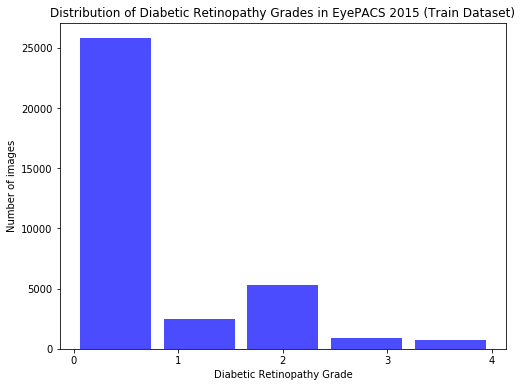

   Diagnosis Grade  Frequency
0                0      25810
1                1       2443
2                2       5292
3                3        873
4                4        708


In [6]:
# Create a histogram of the diabetic retinopathy grades for train_df
plt.figure(figsize=(8, 6))
plt.hist(train_df['diagnosis'], bins=5, color='blue', alpha=0.7, rwidth=0.85)
plt.xlabel('Diabetic Retinopathy Grade')
plt.ylabel('Number of images')
plt.title('Distribution of Diabetic Retinopathy Grades in EyePACS 2015 (Train Dataset)')
plt.xticks(range(5), ['0', '1', '2', '3', '4'])
plt.show()

# Create a table to show grade distribution in train_df
train_grade_distribution = train_df['diagnosis'].value_counts().sort_index()
train_grade_distribution_table = pd.DataFrame({'Diagnosis Grade': train_grade_distribution.index, 'Frequency': train_grade_distribution.values})
print(train_grade_distribution_table)

# VALIDATION DF
The APTOS 2019 Kaggle dataset [46] consists of 3662 retina images with different image sizes. Only the ground truths of the training images are publicly available. The dataset is classified into five DR stages. In addition, 1805 of the images are normal and 1857 are DR images. The distribution of the dataset is imbalanced, with most of the images normal.

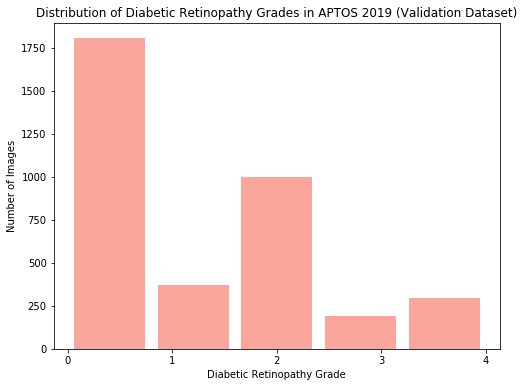

   Diagnosis Grade  Frequency
0                0       1805
1                1        370
2                2        999
3                3        193
4                4        295


In [7]:
# Create a histogram of the diabetic retinopathy grades for val_df
plt.figure(figsize=(8, 6))
plt.hist(val_df['diagnosis'], bins=5, color='salmon', alpha=0.7, rwidth=0.85)
plt.xlabel('Diabetic Retinopathy Grade')
plt.ylabel('Number of Images')
plt.title('Distribution of Diabetic Retinopathy Grades in APTOS 2019 (Validation Dataset)')
plt.xticks(range(5), ['0', '1', '2', '3', '4'])
plt.show()

# Create a table to show grade distribution in val_df
val_grade_distribution = val_df['diagnosis'].value_counts().sort_index()
val_grade_distribution_table = pd.DataFrame({'Diagnosis Grade': val_grade_distribution.index, 'Frequency': val_grade_distribution.values})
print(val_grade_distribution_table)

# **TEST DF**

The Messidor-2 dataset is a collection of Diabetic Retinopathy (DR) examinations, each consisting of two macula-centered eye fundus images (one per eye). Only macula-centered images were included in the dataset. Messidor-2 contains 874 examinations (1748 images). The dataset comes with a spreadsheet containing image pairing.
This is a preprocessed version of Messidor-2 dataset available at Messidor-2 in order to delete the excess of black background. The Diabetic Retinopathy grades (as well as DME and Gradability) are from MESSIDOR-2 DR Grades.

Please cite the following paper if you use this data in your research/study:

Krause, J. et al. Grader variability and the importance of reference standards
for evaluating machine learning models for diabetic retinopathy.
Ophthalmology (2018). doi:10.1016/j.ophtha.2018.01.034

About the data:

The csv file contains adjudicated 5 point ICDR grades and Referable DME grades
for the Messidor 2 dataset [1]. Each row of the csv corresponds to a single
image, with 4 columns labeled as:

image_id, adjudicated_dr_grade, adjudicated_dme, adjudicated_gradable

Column descriptions:

image_id: Filename as provided in the Messidor 2 dataset.

adjudicated_dr_grade: 5 point ICDR grade
  0=None
  1=Mild DR
  2=Moderate DR
  3=Severe DR
  4=PDR

adjudicated_dme: Referable DME defined by Hard exudates within 1DD
  0=No Referable DME
  1=Referable DME

adjudicated_gradable: Image quality grade.
  0=Ungradable, no DR or DME grade is provided
  1=Gradable, both DR and DME were graded.
Please note that adjudicated_dr_grade and adjudicated_dme columns will be empty
for images where adjudicated_gradable=0.

The grading was done according to the adjudication protocol described in
Krause et al. [2], which demonstrated improvements in data and model quality
over Gulshan et al. [3] using adjudicated data.

References:

[1] Decencière  E, Etienne  D, Xiwei  Z,  et al.  Feedback on a publicly distributed image database: the Messidor database.  Image Anal Stereol. 2014;33(3):231-234. doi:10.5566/ias.1155

[2] Krause, J. et al. Grader variability and the importance of reference standards for evaluating machine learning models for diabetic retinopathy. Ophthalmology (2018). doi:10.1016/j.ophtha.2018.01.034

[3] Gulshan, V. et al. Development and Validation of a Deep Learning Algorithm for Detection of Diabetic Retinopathy in Retinal Fundus Photographs. JAMA 316, 2402–2410 (2016)

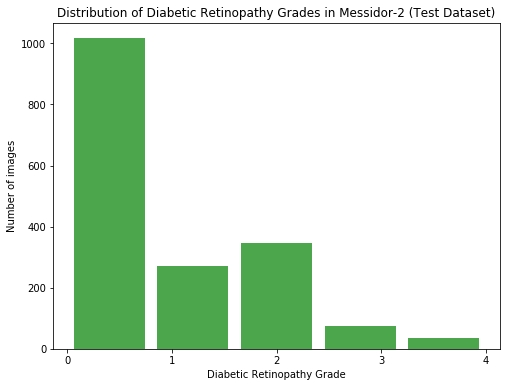

   Diagnosis Grade  Frequency
0                0       1017
1                1        270
2                2        347
3                3         75
4                4         35


In [8]:
# Create a histogram of the diabetic retinopathy grades for test_df
plt.figure(figsize=(8, 6))
plt.hist(test_df['diagnosis'], bins=5, color='green', alpha=0.7, rwidth=0.85)
plt.xlabel('Diabetic Retinopathy Grade')
plt.ylabel('Number of images')
plt.title('Distribution of Diabetic Retinopathy Grades in Messidor-2 (Test Dataset)')
plt.xticks(range(5), ['0', '1', '2', '3', '4'])
plt.show()

# Create a table to show grade distribution in test_df
test_grade_distribution = test_df['diagnosis'].value_counts().sort_index()
test_grade_distribution_table = pd.DataFrame({'Diagnosis Grade': test_grade_distribution.index, 'Frequency': test_grade_distribution.values})
print(test_grade_distribution_table)

In [9]:
# Let's shuffle the datasets
train_df = train_df.sample(frac=1).reset_index(drop=True)
val_df = val_df.sample(frac=1).reset_index(drop=True)
test_df = test_df.sample(frac=1).reset_index(drop=True)

# Display the shapes of the shuffled datasets
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(35126, 2)
(3662, 2)
(1744, 2)


## PREPROCESSING

In [10]:
def display_samples(df, columns=4, rows=3):
    fig=plt.figure(figsize=(5*columns, 4*rows))

    for i in range(columns*rows):
        image_path = df.loc[i,'id_code']
        image_id = df.loc[i,'diagnosis']
        img = cv2.imread(f'{image_path}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        #img = crop_image_from_gray(img)
        img = cv2.resize(img, (im_size,im_size))
        img = cv2.addWeighted(img,4,cv2.GaussianBlur(img, (0,0), im_size/40) ,-4 ,128)
        
        fig.add_subplot(rows, columns, i+1)
        plt.title(image_id)
        plt.imshow(img)
    
    plt.tight_layout()


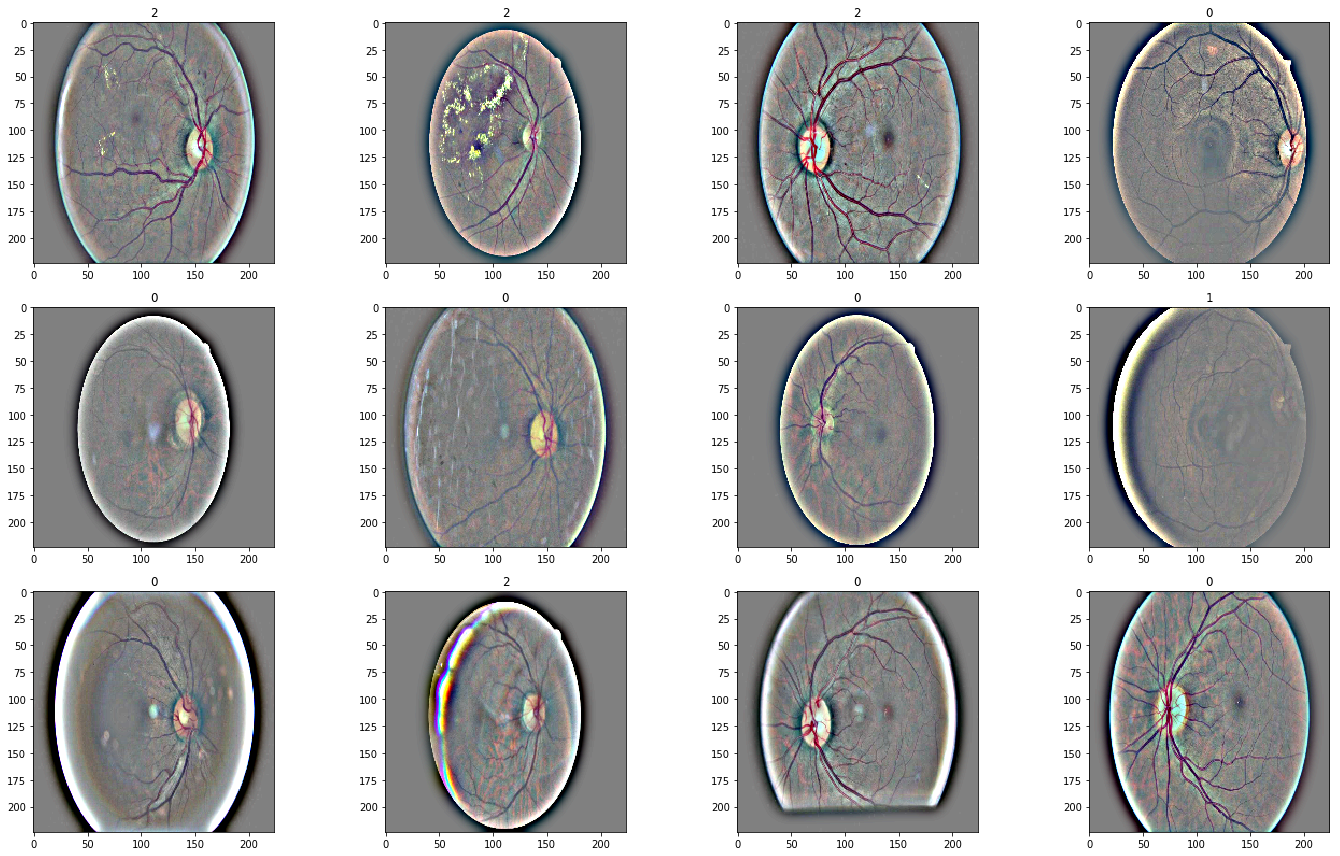

In [11]:
display_samples(train_df)

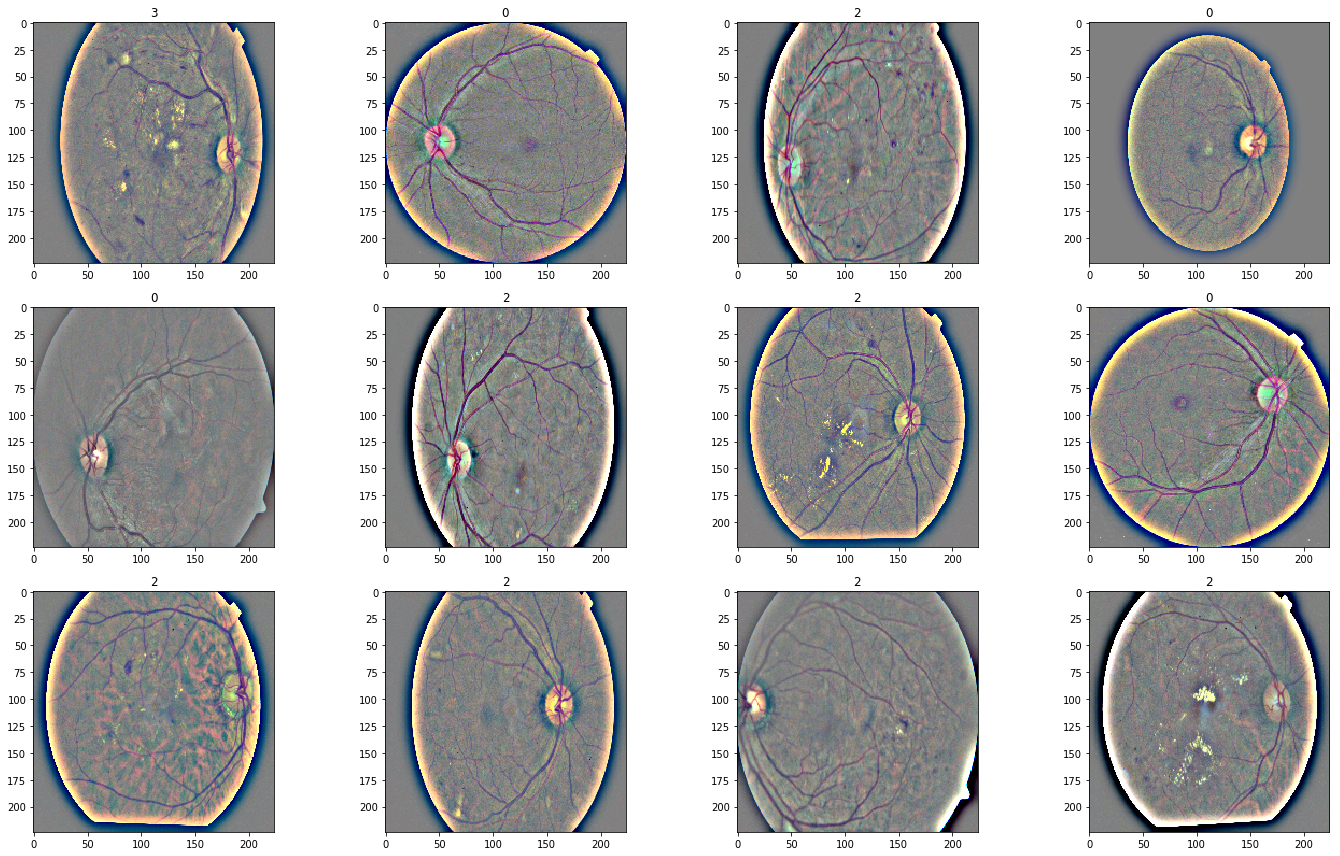

In [12]:
display_samples(val_df)

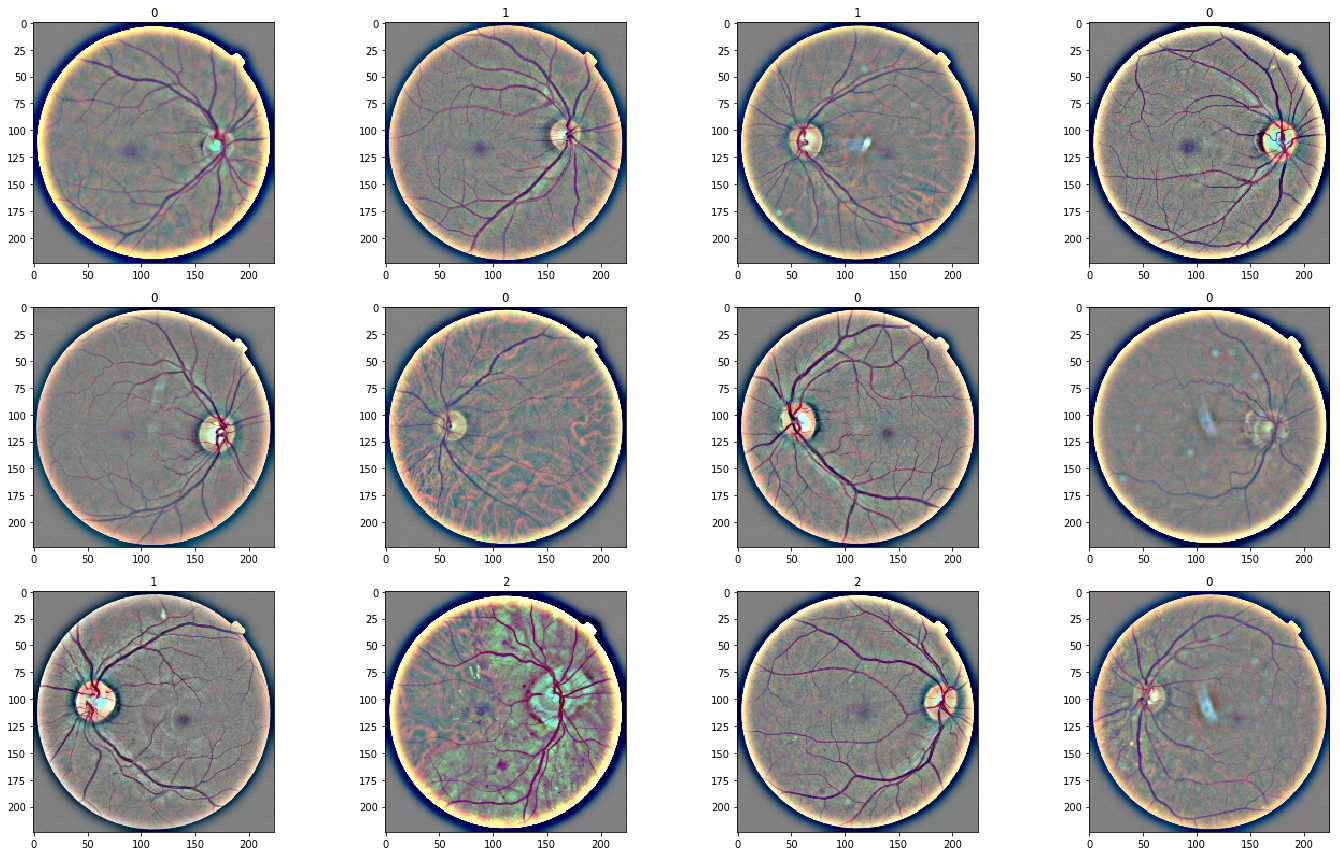

In [13]:
display_samples(test_df)

# Processing Images

**Updated Ben Grahm preprocessing method by Chatpatanasiri (crop function: : https://www.kaggle.com/ratthachat/aptos-updated-preprocessing-ben-s-cropping )**

crop_image1(img, tol=7): This function takes an input image img and a tolerance parameter tol. It creates a binary mask based on pixel intensity values greater than the tolerance value. It then crops the input image to include only the non-zero intensity regions based on the mask. The resulting cropped image is returned.

crop_image_from_gray(img, tol=7): This function performs a similar operation as crop_image1, but it can handle both grayscale (ndim==2) and color (ndim==3) images. For grayscale images, it directly applies the cropping operation. For color images, it first converts the image to grayscale, applies the cropping, and then extracts the corresponding color channels from the cropped region. If the cropped region is completely dark (all pixels below the tolerance threshold), the original image is returned.

preprocess_image(image_path, desired_size=224): This function reads an image from the specified image_path. It converts the image to RGB color space, then applies the crop_image_from_gray function to remove dark or unimportant areas. The image is then resized to the desired size using bilinear interpolation. A weighted combination of the image and a Gaussian-blurred version is performed, enhancing edges and details. The resulting preprocessed image is returned.

preprocess_image_old(image_path, desired_size=224): This is a simplified version of the previous preprocessing function. It doesn't include the cropping step based on pixel intensity. Instead, it directly resizes the image to the desired size and applies a similar weighted combination of the image and Gaussian blur.

@article{Chatpatanasiri2019_APTOS_Preprocess,
title = "APTOS : Eye Preprocessing in Diabetic Retinopathy",
author = "Chatpatanasiri, Ratthachat",
journal = "https://www.kaggle.com/",
year = "2019",
url = "\url{https://www.kaggle.com/ratthachat/aptos-eye-preprocessing-in-diabetic-retinopathy}",
note = "[Online; accessed DD-MM-YYYY]"
}

In [14]:
def crop_image1(img,tol=7):
    # img is image data
    # tol  is tolerance
        
    mask = img>tol
    return img[np.ix_(mask.any(1),mask.any(0))]

def crop_image_from_gray(img,tol=7):
    if img.ndim ==2:
        mask = img>tol
        return img[np.ix_(mask.any(1),mask.any(0))]
    elif img.ndim==3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img>tol
        
        check_shape = img[:,:,0][np.ix_(mask.any(1),mask.any(0))].shape[0]
        if (check_shape == 0): # image is too dark so that we crop out everything,
            return img # return original image
        else:
            img1=img[:,:,0][np.ix_(mask.any(1),mask.any(0))]
            img2=img[:,:,1][np.ix_(mask.any(1),mask.any(0))]
            img3=img[:,:,2][np.ix_(mask.any(1),mask.any(0))]
            img = np.stack([img1,img2,img3],axis=-1)
        return img

def preprocess_image(image_path, desired_size=224):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_image_from_gray(img)
    img = cv2.resize(img, (desired_size,desired_size))
    img = cv2.addWeighted(img,4,cv2.GaussianBlur(img, (0,0), desired_size/30) ,-4 ,128)
    
    return img

def preprocess_image_old(image_path, desired_size=224):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    #img = crop_image_from_gray(img)
    img = cv2.resize(img, (desired_size,desired_size))
    img = cv2.addWeighted(img,4,cv2.GaussianBlur(img, (0,0), desired_size/40) ,-4 ,128)
    
    return img

__UPDATE:__ Here we are reading just the validation set. In order to use 224x224 images, we are going to load one bucket at a time only when needed. This will let our code run without memory-related errors.

In [15]:
# validation set
N = val_df.shape[0]
x_val = np.empty((N, im_size, im_size, 3), dtype=np.uint8)

for i, image_id in enumerate(tqdm_notebook(val_df['id_code'])):
    x_val[i, :, :, :] = preprocess_image(
        f'{image_id}',
        desired_size = im_size
    )

In [17]:
# Create a directory to store the processed validation images
output_dir = '/kaggle/working/processed_images'
os.makedirs(output_dir, exist_ok=True)

# Save the processed validation images
for i, image_id in enumerate(tqdm_notebook(val_df['id_code'])):
    output_path = os.path.join(output_dir, f'{image_id}.png')
    cv2.imwrite(output_path, x_val[i])

In [18]:
# Load the labels for the datasets
y_train = train_df['diagnosis'].values
y_val = val_df['diagnosis'].values
y_test = test_df['diagnosis'].values

# Display the shapes of the target arrays
print("Train Labels Shape:", y_train.shape)
print("Validation Labels Shape:", y_val.shape)
print("Test Labels Shape:", y_test.shape)

Train Labels Shape: (35126,)
Validation Labels Shape: (3662,)
Test Labels Shape: (1744,)


In [19]:
# delete the uneeded df
del new_train
del old_train
del val_df
gc.collect()

27081

# Creating keras callback for QWK
---
Because our main metric in this problem is QWK, we have to make a function that calculate the QWK for every epoch and also saving the model that got the highest score. 
I had to change this function, in order to consider the best kappa score among all the buckets.

In [20]:
class Metrics(Callback):

    def on_epoch_end(self, epoch, logs={}):
        X_val, y_val = self.validation_data[:2]
        
        y_pred = self.model.predict(X_val)
        
        coef = [0.5, 1.5, 2.5, 3.5]

        for i, pred in enumerate(y_pred):
            if pred < coef[0]:
                y_pred[i] = 0
            elif pred >= coef[0] and pred < coef[1]:
                y_pred[i] = 1
            elif pred >= coef[1] and pred < coef[2]:
                y_pred[i] = 2
            elif pred >= coef[2] and pred < coef[3]:
                y_pred[i] = 3
            else:
                y_pred[i] = 4

        _val_kappa = cohen_kappa_score(
            y_val,
            y_pred, 
            weights='quadratic'
        )

        self.val_kappas.append(_val_kappa)

        print(f"val_kappa: {_val_kappa:.4f}")
        
        if _val_kappa == max(self.val_kappas):
            print("Validation Kappa has improved. Saving model.")
            self.model.save('model.h5')

        return

# Data Generator

In [21]:
def create_datagen():
    return ImageDataGenerator(
        horizontal_flip = True,
        vertical_flip = True,
        rotation_range = 160,
        zoom_range=0.35
    )

# Model: ResNet50

In [22]:
resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(im_size,im_size,3)
)

94658560/94653016 [==============================] - 5s 0us/step


**Model Architecture:**
The model uses a Sequential architecture, where layers are stacked sequentially.
A pre-trained ResNet model is added as the initial layer. This leverages the power of transfer learning, enabling the model to learn relevant features from a large dataset.
A Global Average Pooling 2D layer is added to reduce spatial dimensions and aggregate feature information.
A Dropout layer with a dropout rate of 0.5 is added to prevent overfitting by randomly deactivating a fraction of neurons during training.
A Dense (fully connected) layer with a single neuron and linear activation is added as the output layer, suitable for regression tasks where the goal is to predict a continuous output value.

**Compilation:**
The model is compiled with the 'mean_squared_error' loss function, which is appropriate for regression problems. It measures the squared difference between predicted and actual values.
The Adam optimizer is used with a learning rate of 0.0001 and a small decay rate of 1e-6. Adam is an efficient optimizer for training neural networks.
'mae' (Mean Absolute Error) is chosen as the evaluation metric, which provides a measure of the average absolute difference between predictions and ground truth.

**Return:**
The built model is returned, ready for training and evaluation.
Overall, this model architecture leverages the strengths of a pre-trained ResNet for feature extraction and introduces necessary components like Global Average Pooling and Dropout to enhance generalization and prevent overfitting. The choice of loss function, optimizer, and evaluation metric aligns well with the regression problem's nature, aiming to produce accurate continuous predictions.

**Commentary:**
Overall, this model architecture leverages the strengths of a pre-trained ResNet for feature extraction and introduces necessary components like Global Average Pooling and Dropout to enhance generalization and prevent overfitting. The choice of loss function, optimizer, and evaluation metric aligns well with the regression problem's nature, aiming to produce accurate continuous predictions.

In [23]:
def build_model():
    model = Sequential()
    model.add(resnet)
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='linear'))
    
    model.compile(
        loss='mean_squared_error',
        optimizer=Adam(lr=0.0001,decay=1e-6),
        metrics=['mae']
    )
    
    return model

In [24]:
model = build_model()
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet50 (Model)             (None, 7, 7, 2048)        23587712  
_________________________________________________________________
global_average_pooling2d_1 ( (None, 2048)              0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 2048)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 2049      
Total params: 23,589,761
Trainable params: 23,536,641
Non-trainable params: 53,120
_________________________________________________________________


In [26]:
pip install pydot graphviz


Note: you may need to restart the kernel to use updated packages.


In [34]:
from keras.utils.vis_utils import plot_model
from IPython.display import SVG

# Plot the model architecture with shapes
plot_model(model, show_shapes=True)
# Saved as a PNG image


# Training & Evaluation

In [35]:
#train_df = train_df.reset_index(drop=True)
num_bucket = 8
div = round(train_df.shape[0]/num_bucket)

In [36]:
results = pd.DataFrame({
                        'val_loss': [0.0],
                        'val_mean_absolute_error': [0.0],
                        'loss': [0.0], 
                        'mean_absolute_error': [0.0],
                        'bucket': [0.0]
                        })

In [37]:
# I found that changing the nr. of epochs for each bucket helped in terms of performances
epochs = [10,10,10,15,15,20,20,25]
kappa_metrics = Metrics()
kappa_metrics.val_kappas = []

**Update:** I decided to process images in buckets, save them then load them from storage to try and free more memory.

In [38]:
import gc

# Preprocess and save images to working space
for i in range(0, num_bucket):
    print("Bucket Nr: {}".format(i))
    
    if i != (num_bucket - 1):
        N = train_df.iloc[i * div:(1 + i) * div].shape[0]
    else:
        N = train_df.iloc[i * div:].shape[0]
    
    x_train = np.empty((N, im_size, im_size, 3), dtype=np.uint8)
    
    for j, image_id in enumerate(tqdm_notebook(train_df.iloc[i * div:(1 + i) * div, 0])):
        x_train[j, :, :, :] = preprocess_image_old(f'{image_id}', desired_size=im_size)
    
    # Save the preprocessed images to working space
    np.save(f'/kaggle/working/preprocessed_images_bucket_{i}.npy', x_train)
    
    del x_train
    gc.collect()
    print('-' * 40)


Bucket Nr: 0



----------------------------------------
Bucket Nr: 1



----------------------------------------
Bucket Nr: 2



----------------------------------------
Bucket Nr: 3



----------------------------------------
Bucket Nr: 4



----------------------------------------
Bucket Nr: 5



----------------------------------------
Bucket Nr: 6



----------------------------------------
Bucket Nr: 7



----------------------------------------


In [39]:
# Load and train model using preprocessed images
for i in range(0, num_bucket):
    print("Bucket Nr: {}".format(i))
    
    x_train = np.load(f'/kaggle/working/preprocessed_images_bucket_{i}.npy')
    
    if i != (num_bucket - 1):
        data_generator = create_datagen().flow(
            x_train, y_train[i * div:(1 + i) * div], batch_size=BATCH_SIZE
        )
    else:
        data_generator = create_datagen().flow(x_train, y_train[i * div:], batch_size=BATCH_SIZE)
    
    history = model.fit_generator(
        data_generator,
        steps_per_epoch=x_train.shape[0] / BATCH_SIZE,
        epochs=epochs[i],
        validation_data=(x_val, y_val),
        callbacks=[kappa_metrics]
    )
    
    dic = history.history
    df_model = pd.DataFrame(dic)
    df_model['bucket'] = i
    
    results = results.append(df_model)
    
    del data_generator
    del x_train
    gc.collect()
    
    print('-' * 40)

Bucket Nr: 0
Epoch 1/10
138/137 [==============================] - 85s 617ms/step - loss: 1.3360 - mean_absolute_error: 0.8839 - val_loss: 1.2426 - val_mean_absolute_error: 0.8655
val_kappa: 0.6566
Validation Kappa has improved. Saving model.
Epoch 2/10
138/137 [==============================] - 67s 483ms/step - loss: 0.8768 - mean_absolute_error: 0.6952 - val_loss: 0.9265 - val_mean_absolute_error: 0.7600
val_kappa: 0.6864
Validation Kappa has improved. Saving model.
Epoch 3/10
138/137 [==============================] - 66s 476ms/step - loss: 0.7715 - mean_absolute_error: 0.6479 - val_loss: 0.9206 - val_mean_absolute_error: 0.6945
val_kappa: 0.7449
Validation Kappa has improved. Saving model.
Epoch 4/10
138/137 [==============================] - 66s 481ms/step - loss: 0.7048 - mean_absolute_error: 0.6188 - val_loss: 1.0405 - val_mean_absolute_error: 0.8103
val_kappa: 0.6878
Epoch 5/10
138/137 [==============================] - 66s 481ms/step - loss: 0.6662 - mean_absolute_error: 0.594

In [50]:
for i in range(0,num_bucket):
    if i != (num_bucket-1):
        print("Bucket Nr: {}".format(i))
        
        N = train_df.iloc[i*div:(1+i)*div].shape[0]
        x_train = np.empty((N, im_size, im_size, 3), dtype=np.uint8)
        for j, image_id in enumerate(tqdm_notebook(train_df.iloc[i*div:(1+i)*div,0])):
            x_train[j, :, :, :] = preprocess_image_old(f'{image_id}', desired_size = im_size)

        data_generator = create_datagen().flow(x_train, y_train[i*div:(1+i)*div], batch_size=BATCH_SIZE)
        history = model.fit_generator(
                        data_generator,
                        steps_per_epoch=x_train.shape[0] / BATCH_SIZE,
                        epochs=epochs[i],
                        validation_data=(x_val, y_val),
                        callbacks=[kappa_metrics]
                        )
        
        dic = history.history
        df_model = pd.DataFrame(dic)
        df_model['bucket'] = i
    else:
        print("Bucket Nr: {}".format(i))
        
        N = train_df.iloc[i*div:].shape[0]
        x_train = np.empty((N, im_size, im_size, 3), dtype=np.uint8)
        for j, image_id in enumerate(tqdm_notebook(train_df.iloc[i*div:,0])):
            x_train[j, :, :, :] = preprocess_image_old(f'{image_id}', desired_size = im_size)
        data_generator = create_datagen().flow(x_train, y_train[i*div:], batch_size=BATCH_SIZE)
        
        history = model.fit_generator(
                        data_generator,
                        steps_per_epoch=x_train.shape[0] / BATCH_SIZE,
                        epochs=epochs[i],
                        validation_data=(x_val, y_val),
                        callbacks=[kappa_metrics]
                        )
        
        dic = history.history
        df_model = pd.DataFrame(dic)
        df_model['bucket'] = i

    results = results.append(df_model)
    
    del data_generator
    del x_train
    gc.collect()
    
    print('-'*40)

Bucket Nr: 0



Epoch 1/10
138/137 [==============================] - 81s 584ms/step - loss: 1.4131 - mean_absolute_error: 0.9142 - val_loss: 0.9435 - val_mean_absolute_error: 0.6885
val_kappa: 0.7010
Validation Kappa has improved. Saving model.
Epoch 2/10
138/137 [==============================] - 61s 445ms/step - loss: 0.8596 - mean_absolute_error: 0.6953 - val_loss: 0.7663 - val_mean_absolute_error: 0.6567
val_kappa: 0.6791
Epoch 3/10
138/137 [==============================] - 62s 448ms/step - loss: 0.7533 - mean_absolute_error: 0.6455 - val_loss: 0.8176 - val_mean_absolute_error: 0.6431
val_kappa: 0.6872
Epoch 4/10
138/137 [==============================] - 62s 448ms/step - loss: 0.6974 - mean_absolute_error: 0.6155 - val_loss: 0.8817 - val_mean_absolute_error: 0.6571
val_kappa: 0.6287
Epoch 5/10
138/137 [==============================] - 62s 448ms/step - loss: 0.6803 - mean_absolute_error: 0.6056 - val_loss: 0.7627 - val_mean_absolute_error: 0.5784
val_kappa: 0.7566
Validation Kappa has improved


Epoch 1/10
138/137 [==============================] - 65s 469ms/step - loss: 0.5995 - mean_absolute_error: 0.5537 - val_loss: 1.2901 - val_mean_absolute_error: 0.8183
val_kappa: 0.7604
Epoch 2/10
138/137 [==============================] - 62s 448ms/step - loss: 0.5581 - mean_absolute_error: 0.5296 - val_loss: 0.5322 - val_mean_absolute_error: 0.5129
val_kappa: 0.7978
Validation Kappa has improved. Saving model.
Epoch 3/10
138/137 [==============================] - 62s 451ms/step - loss: 0.5600 - mean_absolute_error: 0.5317 - val_loss: 0.5171 - val_mean_absolute_error: 0.5374
val_kappa: 0.8126
Validation Kappa has improved. Saving model.
Epoch 4/10
138/137 [==============================] - 62s 450ms/step - loss: 0.5382 - mean_absolute_error: 0.5191 - val_loss: 0.5321 - val_mean_absolute_error: 0.5178
val_kappa: 0.8043
Epoch 5/10
138/137 [==============================] - 62s 448ms/step - loss: 0.5323 - mean_absolute_error: 0.5156 - val_loss: 0.5076 - val_mean_absolute_error: 0.5364
va


Epoch 1/10
138/137 [==============================] - 65s 471ms/step - loss: 0.5925 - mean_absolute_error: 0.5430 - val_loss: 0.6497 - val_mean_absolute_error: 0.5172
val_kappa: 0.7454
Epoch 2/10
138/137 [==============================] - 62s 450ms/step - loss: 0.5504 - mean_absolute_error: 0.5219 - val_loss: 0.8227 - val_mean_absolute_error: 0.5689
val_kappa: 0.7548
Epoch 3/10
138/137 [==============================] - 63s 454ms/step - loss: 0.5592 - mean_absolute_error: 0.5244 - val_loss: 0.5334 - val_mean_absolute_error: 0.4826
val_kappa: 0.8203
Validation Kappa has improved. Saving model.
Epoch 4/10
138/137 [==============================] - 62s 448ms/step - loss: 0.5267 - mean_absolute_error: 0.5067 - val_loss: 1.1176 - val_mean_absolute_error: 0.6419
val_kappa: 0.6081
Epoch 5/10
138/137 [==============================] - 62s 449ms/step - loss: 0.5352 - mean_absolute_error: 0.5161 - val_loss: 0.6905 - val_mean_absolute_error: 0.4973
val_kappa: 0.7474
Epoch 6/10
138/137 [=========


Epoch 1/15
138/137 [==============================] - 65s 470ms/step - loss: 0.5528 - mean_absolute_error: 0.5253 - val_loss: 1.3195 - val_mean_absolute_error: 0.7494
val_kappa: 0.5263
Epoch 2/15
138/137 [==============================] - 61s 445ms/step - loss: 0.5300 - mean_absolute_error: 0.5083 - val_loss: 1.4118 - val_mean_absolute_error: 0.7468
val_kappa: 0.4404
Epoch 3/15
138/137 [==============================] - 62s 448ms/step - loss: 0.5136 - mean_absolute_error: 0.4981 - val_loss: 1.1193 - val_mean_absolute_error: 0.6254
val_kappa: 0.5687
Epoch 4/15
138/137 [==============================] - 62s 447ms/step - loss: 0.5091 - mean_absolute_error: 0.4957 - val_loss: 0.7122 - val_mean_absolute_error: 0.4966
val_kappa: 0.7445
Epoch 5/15
138/137 [==============================] - 62s 449ms/step - loss: 0.4949 - mean_absolute_error: 0.4873 - val_loss: 0.6297 - val_mean_absolute_error: 0.4784
val_kappa: 0.7756
Epoch 6/15
138/137 [==============================] - 61s 444ms/step - los


Epoch 1/15
138/137 [==============================] - 65s 470ms/step - loss: 0.5720 - mean_absolute_error: 0.5337 - val_loss: 0.6038 - val_mean_absolute_error: 0.5337
val_kappa: 0.7934
Epoch 2/15
138/137 [==============================] - 61s 446ms/step - loss: 0.5558 - mean_absolute_error: 0.5248 - val_loss: 0.9741 - val_mean_absolute_error: 0.6275
val_kappa: 0.6331
Epoch 3/15
138/137 [==============================] - 62s 447ms/step - loss: 0.5234 - mean_absolute_error: 0.5081 - val_loss: 0.9927 - val_mean_absolute_error: 0.7924
val_kappa: 0.7584
Epoch 4/15
138/137 [==============================] - 62s 450ms/step - loss: 0.5040 - mean_absolute_error: 0.4965 - val_loss: 0.8906 - val_mean_absolute_error: 0.5575
val_kappa: 0.6711
Epoch 5/15
138/137 [==============================] - 62s 449ms/step - loss: 0.5127 - mean_absolute_error: 0.5031 - val_loss: 0.6294 - val_mean_absolute_error: 0.6009
val_kappa: 0.8106
Epoch 6/15
138/137 [==============================] - 61s 445ms/step - los


Epoch 1/20
138/137 [==============================] - 65s 474ms/step - loss: 0.5473 - mean_absolute_error: 0.5119 - val_loss: 0.5856 - val_mean_absolute_error: 0.5248
val_kappa: 0.8214
Validation Kappa has improved. Saving model.
Epoch 2/20
138/137 [==============================] - 62s 450ms/step - loss: 0.4890 - mean_absolute_error: 0.4780 - val_loss: 0.5379 - val_mean_absolute_error: 0.4676
val_kappa: 0.8287
Validation Kappa has improved. Saving model.
Epoch 3/20
138/137 [==============================] - 62s 451ms/step - loss: 0.5019 - mean_absolute_error: 0.4883 - val_loss: 0.5232 - val_mean_absolute_error: 0.5185
val_kappa: 0.8431
Validation Kappa has improved. Saving model.
Epoch 4/20
138/137 [==============================] - 63s 454ms/step - loss: 0.4698 - mean_absolute_error: 0.4708 - val_loss: 0.7267 - val_mean_absolute_error: 0.5399
val_kappa: 0.7294
Epoch 5/20
138/137 [==============================] - 63s 459ms/step - loss: 0.4579 - mean_absolute_error: 0.4592 - val_loss


Epoch 1/20
138/137 [==============================] - 67s 483ms/step - loss: 0.5183 - mean_absolute_error: 0.4895 - val_loss: 0.4481 - val_mean_absolute_error: 0.4161
val_kappa: 0.8461
Validation Kappa has improved. Saving model.
Epoch 2/20
138/137 [==============================] - 63s 457ms/step - loss: 0.4840 - mean_absolute_error: 0.4720 - val_loss: 0.5236 - val_mean_absolute_error: 0.4796
val_kappa: 0.8154
Epoch 3/20
138/137 [==============================] - 63s 455ms/step - loss: 0.4630 - mean_absolute_error: 0.4581 - val_loss: 0.6460 - val_mean_absolute_error: 0.4819
val_kappa: 0.7547
Epoch 4/20
138/137 [==============================] - 63s 454ms/step - loss: 0.4718 - mean_absolute_error: 0.4645 - val_loss: 0.5381 - val_mean_absolute_error: 0.5511
val_kappa: 0.8211
Epoch 5/20
138/137 [==============================] - 62s 450ms/step - loss: 0.4563 - mean_absolute_error: 0.4588 - val_loss: 0.4797 - val_mean_absolute_error: 0.4432
val_kappa: 0.8575
Validation Kappa has improved


Epoch 1/25
138/137 [==============================] - 69s 497ms/step - loss: 0.4993 - mean_absolute_error: 0.4830 - val_loss: 0.7247 - val_mean_absolute_error: 0.5037
val_kappa: 0.7237
Epoch 2/25
138/137 [==============================] - 64s 466ms/step - loss: 0.4975 - mean_absolute_error: 0.4812 - val_loss: 0.5429 - val_mean_absolute_error: 0.4903
val_kappa: 0.8179
Epoch 3/25
138/137 [==============================] - 64s 462ms/step - loss: 0.4626 - mean_absolute_error: 0.4711 - val_loss: 0.5109 - val_mean_absolute_error: 0.4339
val_kappa: 0.8262
Epoch 4/25
138/137 [==============================] - 64s 465ms/step - loss: 0.4756 - mean_absolute_error: 0.4651 - val_loss: 0.6693 - val_mean_absolute_error: 0.5742
val_kappa: 0.7508
Epoch 5/25
138/137 [==============================] - 64s 467ms/step - loss: 0.4294 - mean_absolute_error: 0.4446 - val_loss: 0.6464 - val_mean_absolute_error: 0.5616
val_kappa: 0.7961
Epoch 6/25
138/137 [==============================] - 64s 462ms/step - los

In [40]:
results = results.iloc[1:]
results['kappa'] = kappa_metrics.val_kappas
results = results.reset_index()
results = results.rename(index=str, columns={"index": "epoch"})
print(max(results.kappa))

0.8556550641344352


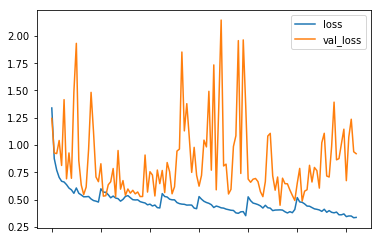

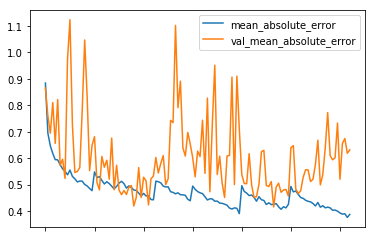

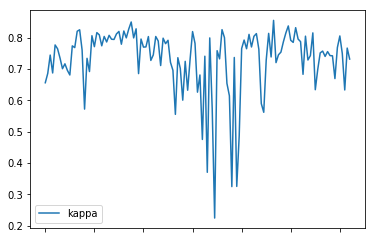

In [41]:
results[['loss', 'val_loss']].plot()
results[['mean_absolute_error', 'val_mean_absolute_error']].plot()
results[['kappa']].plot()
results.to_csv('model_results.csv',index=False)

# QWK Optimizer
See Abhishek optimizer [here](https://www.kaggle.com/abhishek/optimizer-for-quadratic-weighted-kappa)

In [42]:
class OptimizedRounder(object):
    def __init__(self):
        self.coef_ = 0

    def _kappa_loss(self, coef, X, y):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 0
            elif pred >= coef[0] and pred < coef[1]:
                X_p[i] = 1
            elif pred >= coef[1] and pred < coef[2]:
                X_p[i] = 2
            elif pred >= coef[2] and pred < coef[3]:
                X_p[i] = 3
            else:
                X_p[i] = 4

        ll = cohen_kappa_score(y, X_p, weights='quadratic')
        return -ll

    def fit(self, X, y):
        loss_partial = partial(self._kappa_loss, X=X, y=y)
        initial_coef = [0.5, 1.5, 2.5, 3.5]
        self.coef_ = scipy.optimize.minimize(loss_partial, initial_coef, method='nelder-mead')
        print(-loss_partial(self.coef_['x']))

    def predict(self, X, coef):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 0
            elif pred >= coef[0] and pred < coef[1]:
                X_p[i] = 1
            elif pred >= coef[1] and pred < coef[2]:
                X_p[i] = 2
            elif pred >= coef[2] and pred < coef[3]:
                X_p[i] = 3
            else:
                X_p[i] = 4
        return X_p

    def coefficients(self):
        return self.coef_['x']

In [43]:
from functools import partial

In [44]:
model.load_weights('model.h5')
y_val_pred = model.predict(x_val)

optR = OptimizedRounder()
optR.fit(y_val_pred, y_val)
coefficients = optR.coefficients()
print(f'Coefficients: {coefficients}')
y_val_pred = optR.predict(y_val_pred, coefficients)

score = cohen_kappa_score(y_val_pred, y_val, weights='quadratic')

print('Optimized Validation QWK score: {}'.format(score))
print('Not Optimized Validation QWK score: {}'.format(max(results.kappa)))

0.862960916911695
Coefficients: [0.52960313 1.30357816 2.60657071 3.5127878 ]
Optimized Validation QWK score: 0.862960916911695
Not Optimized Validation QWK score: 0.8556550641344352


# Save final model

In [45]:
model.save('ResNet50_model.h5')

In [46]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load the model and predict on the validation data
model.load_weights('model.h5')
y_val_pred = model.predict(x_val)

# Instantiate an OptimizedRounder object and fit on the validation data
optR = OptimizedRounder()
optR.fit(y_val_pred, y_val)
coefficients = optR.coefficients()
print(f'Coefficients: {coefficients}')

# Get the predicted labels using the optimized coefficients
y_val_pred_rounded = optR.predict(y_val_pred, coefficients)

0.862960916911695
Coefficients: [0.52960313 1.30357816 2.60657071 3.5127878 ]


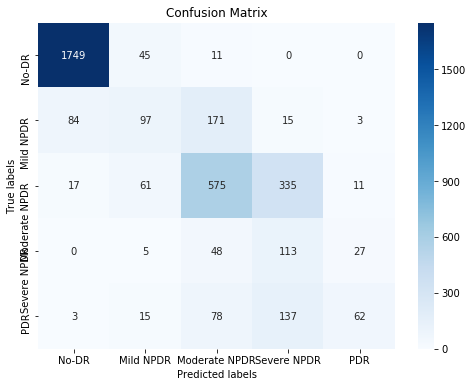

In [47]:
# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred_rounded)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', ax=ax)

# Add labels, title, and axis ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No-DR', 'Mild NPDR', 'Moderate NPDR', 'Severe NPDR', 'PDR'])
ax.yaxis.set_ticklabels(['No-DR', 'Mild NPDR', 'Moderate NPDR', 'Severe NPDR', 'PDR'])
plt.show()

In [48]:
from sklearn.metrics import confusion_matrix, classification_report

# assuming y_val and y_val_pred_rounded are the true and predicted labels respectively
cm = confusion_matrix(y_val, y_val_pred_rounded)

# Calculate precision, recall, and accuracy
report = classification_report(y_val, y_val_pred_rounded, target_names=['No-DR', 'Mild NPDR', 'Moderate NPDR', 'Severe NPDR', 'PDR'])

# Print confusion matrix, precision, recall, and accuracy
print('Confusion Matrix:\n', cm)
print('Classification Report:\n', report)

Confusion Matrix:
 [[1749   45   11    0    0]
 [  84   97  171   15    3]
 [  17   61  575  335   11]
 [   0    5   48  113   27]
 [   3   15   78  137   62]]
Classification Report:
                precision    recall  f1-score   support

        No-DR       0.94      0.97      0.96      1805
    Mild NPDR       0.43      0.26      0.33       370
Moderate NPDR       0.65      0.58      0.61       999
  Severe NPDR       0.19      0.59      0.28       193
          PDR       0.60      0.21      0.31       295

     accuracy                           0.71      3662
    macro avg       0.56      0.52      0.50      3662
 weighted avg       0.75      0.71      0.71      3662



In [61]:
# Calculate Quadratic Weighted Kappa (QWK)
qwk = cohen_kappa_score(y_val, y_val_pred_rounded, weights='quadratic')
# Calculate accuracy for binary classification
acc = accuracy_score(y_val, y_val_pred_rounded)

# Print QWK score
print('Quadratic Weighted Kappa (QWK) for multiple classification:', qwk)
# Print accuracy
print('Accuracy for multiple classification:', acc)

Quadratic Weighted Kappa (QWK) for multiple classification: 0.862960916911695
Accuracy for multiple classification: 0.7089022392135446


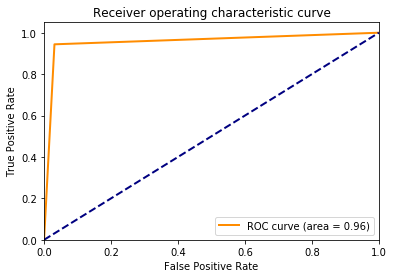

In [49]:
# Map 0 to 'No DR' and 1,2,3,4 to 'DR' in y_true
y_true_binary = np.where(y_val == 0, 0, 1)
y_val_pred_rounded_binary = np.where(y_val_pred_rounded == 0, 0, 1)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_binary, y_val_pred_rounded_binary, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic curve')
plt.legend(loc="lower right")
plt.show()

In [59]:
# Calculate Quadratic Weighted Kappa (QWK)
qwk = cohen_kappa_score(y_true_binary, y_val_pred_rounded_binary, weights='quadratic')
# Calculate accuracy for binary classification
acc = accuracy_score(y_true_binary, y_val_pred_rounded_binary)

# Print QWK score
print('Quadratic Weighted Kappa (QWK) for binary classification:', qwk)
# Print accuracy
print('Accuracy for binary classification:', acc)


Quadratic Weighted Kappa (QWK) for binary classification: 0.9126309633408517
Accuracy for binary classification: 0.9563080283997816


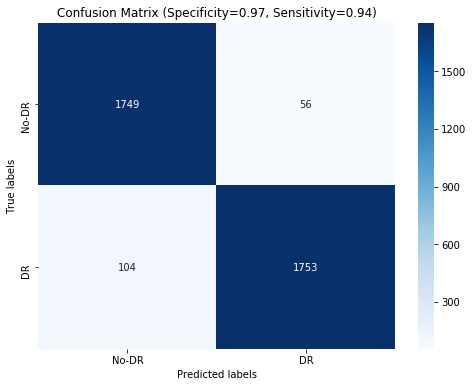

In [51]:
# Compute confusion matrix
cm = confusion_matrix(y_true_binary, y_val_pred_rounded_binary)

# Calculate specificity and sensitivity
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

# Display confusion matrix with percentages
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', ax=ax)

# Add labels, title, and axis ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix (Specificity={:.2f}, Sensitivity={:.2f})'.format(specificity, sensitivity))
ax.xaxis.set_ticklabels(['No-DR', 'DR'])
ax.yaxis.set_ticklabels(['No-DR', 'DR'])
plt.show()

In [52]:
report_binary = classification_report(y_true_binary, y_val_pred_rounded_binary, target_names=['No-DR', 'DR'])
print('Classification Report:\n', report_binary)

Classification Report:
               precision    recall  f1-score   support

       No-DR       0.94      0.97      0.96      1805
          DR       0.97      0.94      0.96      1857

    accuracy                           0.96      3662
   macro avg       0.96      0.96      0.96      3662
weighted avg       0.96      0.96      0.96      3662



# Evaluation on Test Dataset (Messidor)

In [53]:
# Preprocess and store test images
N_test = test_df.shape[0]
x_test = np.empty((N_test, im_size, im_size, 3), dtype=np.uint8)

for i, image_id in enumerate(tqdm_notebook(test_df['id_code'])):
    x_test[i, :, :, :] = preprocess_image(
        f'{image_id}',
        desired_size=im_size
    )

# Save the preprocessed test images to working space
np.save('/kaggle/working/preprocessed_test_images.npy', x_test)


In [54]:
# Load preprocessed test images
x_test = np.load('/kaggle/working/preprocessed_test_images.npy')

# Make predictions on the preprocessed test images
y_pred = model.predict(x_test)

# Perform any necessary post-processing on the predictions if needed

# Evaluate the model's performance on the test set
test_loss, test_mae = model.evaluate(x_test, y_test)  # Replace y_test with your actual test labels

# Print or display the evaluation results
print("Test Loss:", test_loss)
print("Test Mean Absolute Error:", test_mae)


1744/1744 [==============================] - 4s 2ms/step
Test Loss: 0.6261970726175046
Test Mean Absolute Error: 0.4917174036349725


0.6762659751986105
Coefficients: [0.56632087 1.35417489 1.84476393 3.89210897]


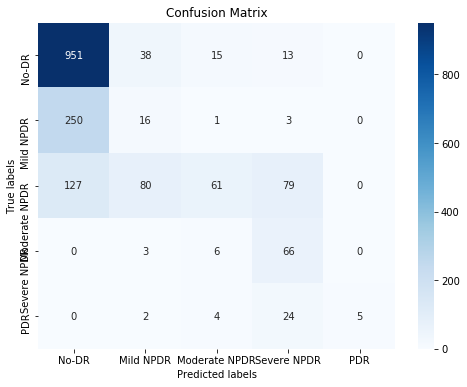

In [55]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load the model and predict on the test data
model.load_weights('model.h5')
y_test_pred = model.predict(x_test)

# Instantiate an OptimizedRounder object and fit on the test data predictions
optR = OptimizedRounder()
optR.fit(y_test_pred, y_test)  # Assuming y_test is your ground truth test labels
coefficients = optR.coefficients()
print(f'Coefficients: {coefficients}')

# Get the predicted labels using the optimized coefficients
y_test_pred_rounded = optR.predict(y_test_pred, coefficients)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred_rounded)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', ax=ax)

# Add labels, title, and axis ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')
ax.xaxis.set_ticklabels(['No-DR', 'Mild NPDR', 'Moderate NPDR', 'Severe NPDR', 'PDR'])
ax.yaxis.set_ticklabels(['No-DR', 'Mild NPDR', 'Moderate NPDR', 'Severe NPDR', 'PDR'])

# Show the plot
plt.show()


In [56]:
from sklearn.metrics import classification_report

# Calculate precision, recall, and accuracy
report = classification_report(y_test, y_test_pred_rounded, target_names=['No-DR', 'Mild NPDR', 'Moderate NPDR', 'Severe NPDR', 'PDR'])

# Print confusion matrix, precision, recall, and accuracy
print('Confusion Matrix:\n', cm)
print('Classification Report:\n', report)


Confusion Matrix:
 [[951  38  15  13   0]
 [250  16   1   3   0]
 [127  80  61  79   0]
 [  0   3   6  66   0]
 [  0   2   4  24   5]]
Classification Report:
                precision    recall  f1-score   support

        No-DR       0.72      0.94      0.81      1017
    Mild NPDR       0.12      0.06      0.08       270
Moderate NPDR       0.70      0.18      0.28       347
  Severe NPDR       0.36      0.88      0.51        75
          PDR       1.00      0.14      0.25        35

     accuracy                           0.63      1744
    macro avg       0.58      0.44      0.39      1744
 weighted avg       0.61      0.63      0.57      1744



In [64]:
# Calculate Quadratic Weighted Kappa (QWK)
qwk = cohen_kappa_score(y_test, y_test_pred_rounded, weights='quadratic')
# Calculate accuracy for binary classification
acc = accuracy_score(y_test, y_test_pred_rounded)

# Print QWK score
print('Quadratic Weighted Kappa (QWK) for multiple classification:', qwk)
# Print accuracy
print('Accuracy for multiple classification:', acc)

Quadratic Weighted Kappa (QWK) for multiple classification: 0.6762659751986105
Accuracy for multiple classification: 0.6301605504587156


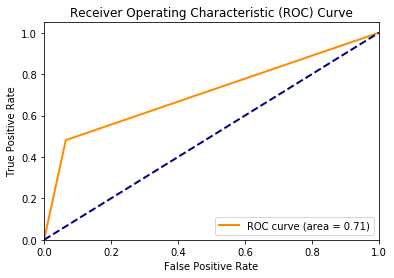

In [57]:
# Map 0 to 'No DR' and 1, 2, 3, 4 to 'DR' in y_test
y_test_binary = np.where(y_test == 0, 0, 1)
y_test_pred_rounded_binary = np.where(y_test_pred_rounded == 0, 0, 1)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_binary, y_test_pred_rounded_binary, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

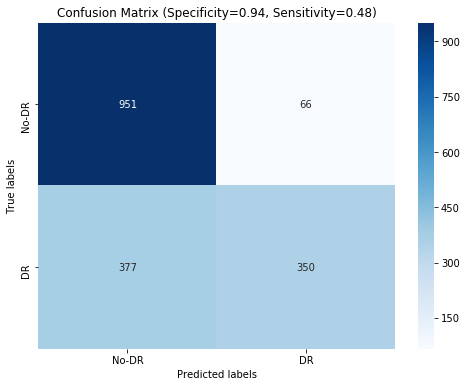

In [62]:
# Compute confusion matrix
cm = confusion_matrix(y_test_binary, y_test_pred_rounded_binary)

# Calculate specificity and sensitivity
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
sensitivity = tp / (tp + fn)

# Display confusion matrix with percentages
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', ax=ax)

# Add labels, title, and axis ticks
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix (Specificity={:.2f}, Sensitivity={:.2f})'.format(specificity, sensitivity))
ax.xaxis.set_ticklabels(['No-DR', 'DR'])
ax.yaxis.set_ticklabels(['No-DR', 'DR'])
plt.show()


In [58]:
# Calculate Quadratic Weighted Kappa (QWK)
qwk = cohen_kappa_score(y_test_binary, y_test_pred_rounded_binary, weights='quadratic')
# Calculate accuracy for binary classification
acc = accuracy_score(y_test_binary, y_test_pred_rounded_binary)

# Print QWK score
print('Quadratic Weighted Kappa (QWK) for binary classification:', qwk)
# Print accuracy
print('Accuracy for binary classification:', acc)

Quadratic Weighted Kappa (QWK) for binary classification: 0.4435891822131063
Accuracy for binary classification: 0.7459862385321101


In [63]:
# Calculate precision, recall, and accuracy
report = classification_report(y_test_binary, y_test_pred_rounded_binary, target_names=['No-DR', 'DR'])

# Print confusion matrix, precision, recall, and accuracy
print('Confusion Matrix:\n', cm)
print('Classification Report:\n', report)


Confusion Matrix:
 [[951  66]
 [377 350]]
Classification Report:
               precision    recall  f1-score   support

       No-DR       0.72      0.94      0.81      1017
          DR       0.84      0.48      0.61       727

    accuracy                           0.75      1744
   macro avg       0.78      0.71      0.71      1744
weighted avg       0.77      0.75      0.73      1744



# Fine Tuning for Messidor